      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  
(545, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (tot

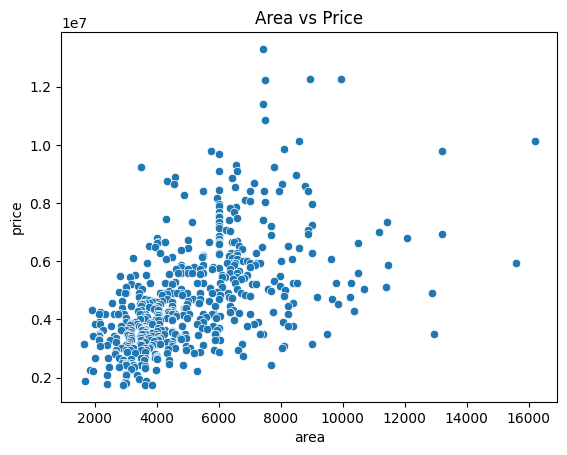

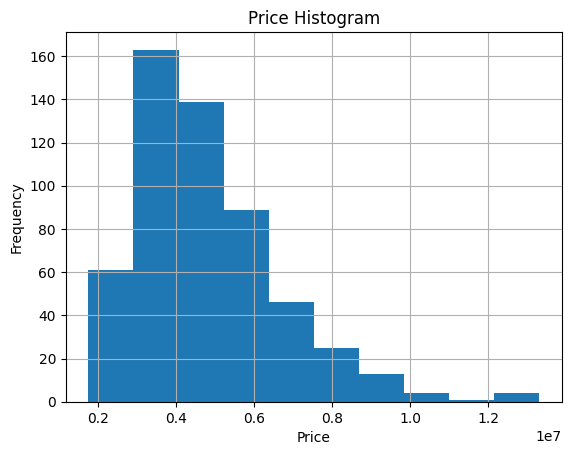

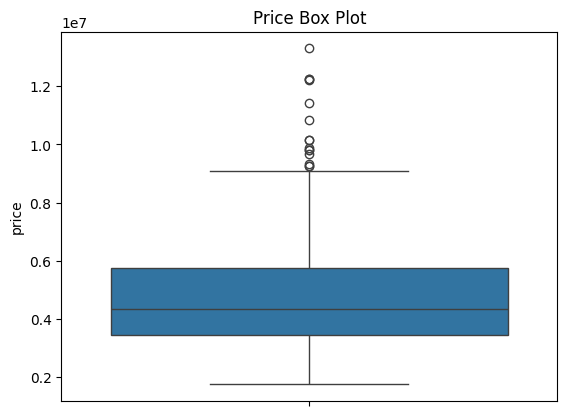

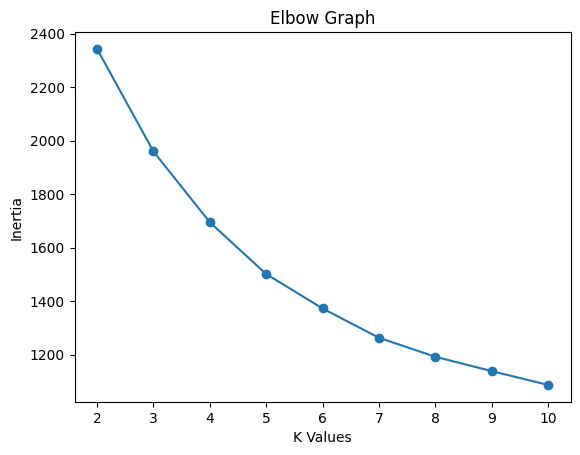

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("Documents/Housing.csv")

# EDA
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())

df_cleaned = df.dropna()

# Scatter Plot
sns.scatterplot(data=df_cleaned, x='area', y='price')
plt.title("Area vs Price")
plt.show()

# Histogram
df_cleaned['price'].hist()
plt.title("Price Histogram")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# Box Plot
sns.boxplot(data=df_cleaned, y='price')
plt.title("Price Box Plot")
plt.show()

# K-Means
X = df_cleaned.select_dtypes(include=['int64', 'float64'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Different K values
k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10]

inertia = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Elbow Graph
plt.plot(k_values, inertia, marker='o')

plt.xlabel("K Values")
plt.ylabel("Inertia")
plt.title("Elbow Graph")

plt.show()